<div class="usecase-title">UC_00207 Dynamic Electricity Demand Forecasting for Smart Cities </div>

<div class="usecase-authors"><b>Authored by: </b> Manoj Chowdary</div>

<div class="usecase-duration"><b>Duration:</b> 120 mins</div>

<div class="usecase-level-skill">
    <div class="usecase-level"><b>Level: </b>Intermediate</div>
    <div class="usecase-skill"><b>Pre-requisite Skills: </b>Python, Pandas, NumPy, Matplotlib, Seaborn, Plotly, Scikit-learn</div>
</div>

<div class="usecase-section-header">Scenario</div>

As an energy data analyst working with a smart city utility provider, I need to acquire, explore, and preprocess large-scale smart meter data so that I can build reliable deep learning models for forecasting electricity demand at the neighborhood level. Accurate demand forecasting supports grid optimisation, reduces energy waste, and enables proactive demand-response strategies during peak periods.

<div class="usecase-section-header">What this use case will teach you</div>

At the end of this use case you will:
- Acquire and load a large-scale smart meter dataset from Kaggle programmatically
- Profile and assess data quality across millions of energy readings
- Perform exploratory data analysis to uncover temporal, seasonal, and neighborhood consumption patterns
- Integrate external weather data aligned by timestamp
- Engineer temporal, lag, rolling, weather-derived, and derived features for time-series forecasting
- Build a leakage-free preprocessing pipeline with scaling, chronological splitting, and sliding window sequence creation
- Export model-ready data artifacts for downstream deep learning model development

<div class="usecase-section-header">Background</div>

Electricity demand forecasting is a critical capability for modern smart grids. Traditional statistical models such as ARIMA and exponential smoothing often fail to capture the nonlinear temporal relationships and complex interactions present in energy consumption data. Deep learning approaches — including LSTM, CNN-LSTM hybrids, and Transformers — can model these intricate dependencies, leading to more accurate and actionable forecasts.

This notebook uses the **UK Smart Meter Dataset** from Kaggle, which contains half-hourly energy consumption readings from approximately 5,500 London households between 2011 and 2014. The dataset also includes hourly weather observations from the Dark Sky API (temperature, humidity, wind speed, etc.) and household demographic classifications using the ACORN system, which serves as a neighborhood proxy. By combining smart meter readings, weather data, and demographic groupings, we build a rich, multi-source dataset suitable for training deep learning forecasting models.

**References:**
- UK Smart Meter Dataset: <a href="https://www.kaggle.com/datasets/jeanmidev/smart-meters-in-london">Kaggle — Smart Meters in London</a>
- ACORN Classification: <a href="https://acorn.caci.co.uk/">CACI ACORN</a>

---

<div class="usecase-section-header">1.1 Install & Import Dependencies</div>

In [14]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                       'pandas', 'numpy', 'matplotlib', 'seaborn', 'plotly',
                       'scikit-learn', 'kagglehub', '--quiet'])


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip3.13 install --upgrade pip


0

In [15]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import MinMaxScaler
from IPython.display import display
import pickle

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

print('All imports successful.')

All imports successful.


<div class="usecase-section-header">1.2 Data Acquisition</div>

We use the **UK Power Networks Smart Meter Dataset** (London households).

The dataset contains:
- **Smart meter readings** — half-hourly energy consumption (kWh) for ~5,500 London households (2011–2014)
- **Weather data** — hourly weather observations (temperature, humidity, wind speed, etc.) from the Dark Sky API
- **Household metadata** — ACORN group classifications (demographic/neighborhood proxies)

The cell below checks if the data already exists in `data/raw/`. If found, it skips the download. Otherwise, it downloads from Kaggle using `kagglehub` and copies the files into `data/raw/`.

In [16]:
import shutil

dataset_path = 'data/raw'
os.makedirs(dataset_path, exist_ok=True)

# Check if raw data already exists by looking for key files
has_halfhourly = os.path.isdir(os.path.join(dataset_path, 'halfhourly_dataset'))
has_weather = os.path.isfile(os.path.join(dataset_path, 'weather_hourly_darksky.csv'))
has_households = os.path.isfile(os.path.join(dataset_path, 'informations_households.csv'))

if has_halfhourly and has_weather and has_households:
    print(f"Raw data already exists in {os.path.abspath(dataset_path)} — skipping download.")
else:
    print("Raw data not found locally. Downloading from Kaggle...")
    import kagglehub
    cache_path = kagglehub.dataset_download("jeanmidev/smart-meters-in-london")
    print(f"Downloaded to cache: {cache_path}")

    # Copy everything from cache into data/raw/
    for item in os.listdir(cache_path):
        src = os.path.join(cache_path, item)
        dst = os.path.join(dataset_path, item)
        if os.path.isdir(src):
            shutil.copytree(src, dst, dirs_exist_ok=True)
        else:
            shutil.copy2(src, dst)

    print(f"All files copied to {os.path.abspath(dataset_path)}")

print(f"\nUsing dataset from: {os.path.abspath(dataset_path)}")

Raw data already exists in /Users/jeevanvarma/Documents/GitHub/Manoj/data/raw — skipping download.

Using dataset from: /Users/jeevanvarma/Documents/GitHub/Manoj/data/raw


In [17]:
# List available files in the dataset directory
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    sub_indent = ' ' * 2 * (level + 1)
    for file in files:
        file_size = os.path.getsize(os.path.join(root, file)) / (1024 * 1024)
        print(f"{sub_indent}{file} ({file_size:.1f} MB)")

raw/
  darksky_parameters_documentation.html (0.1 MB)
  acorn_details.csv (0.1 MB)
  uk_bank_holidays.csv (0.0 MB)
  weather_daily_darksky.csv (0.3 MB)
  informations_households.csv (0.2 MB)
  daily_dataset.csv (335.5 MB)
  weather_hourly_darksky.csv (1.9 MB)
  halfhourly_dataset/
    halfhourly_dataset/
      block_71.csv (62.4 MB)
      block_65.csv (59.9 MB)
      block_59.csv (64.2 MB)
      block_58.csv (66.2 MB)
      block_64.csv (67.9 MB)
      block_70.csv (62.2 MB)
      block_99.csv (71.6 MB)
      block_66.csv (58.2 MB)
      block_72.csv (62.6 MB)
      block_73.csv (61.7 MB)
      block_67.csv (64.3 MB)
      block_98.csv (72.9 MB)
      block_88.csv (63.0 MB)
      block_63.csv (69.9 MB)
      block_77.csv (67.8 MB)
      block_76.csv (69.3 MB)
      block_62.csv (67.1 MB)
      block_89.csv (63.6 MB)
      block_48.csv (71.9 MB)
      block_74.csv (68.9 MB)
      block_60.csv (61.4 MB)
      block_61.csv (63.7 MB)
      block_75.csv (70.1 MB)
      block_49.csv (68.8 MB

<p class="usecase-subsection-header">1.2.1 Load Smart Meter Readings</p>

The dataset has energy readings split across multiple block files. We load and concatenate them into a single DataFrame.

In [18]:
# Find all halfhourly block CSV files
# Files are named block_0.csv ... block_111.csv inside halfhourly_dataset/ subdirectory
block_files = []
for root, dirs, files in os.walk(dataset_path):
    if 'halfhourly' in root.lower():
        for f in sorted(files):
            if f.startswith('block_') and f.endswith('.csv'):
                block_files.append(os.path.join(root, f))

block_files.sort()
print(f"Found {len(block_files)} block file(s)")

# Loading all 112 blocks (~100M+ rows) would exceed memory.
# We load a representative subset of 10 blocks (~5,000+ households).
MAX_BLOCKS = 10
if len(block_files) > MAX_BLOCKS:
    print(f"Limiting to first {MAX_BLOCKS} blocks to keep memory manageable.")
    block_files = block_files[:MAX_BLOCKS]

for bf in block_files:
    print(f"  {os.path.basename(bf)}")

Found 112 block file(s)
Limiting to first 10 blocks to keep memory manageable.
  block_0.csv
  block_1.csv
  block_10.csv
  block_100.csv
  block_101.csv
  block_102.csv
  block_103.csv
  block_104.csv
  block_105.csv
  block_106.csv


In [19]:
# Load and concatenate selected blocks
dfs = []
for i, bf in enumerate(block_files):
    df_block = pd.read_csv(bf)
    dfs.append(df_block)
    print(f"  Block {i} ({os.path.basename(bf)}): {len(df_block):,} rows")

if len(dfs) == 0:
    raise FileNotFoundError(
        f"No block CSV files found under {dataset_path}. "
        "Please verify the dataset downloaded correctly."
    )

df_energy = pd.concat(dfs, ignore_index=True)
del dfs  # free memory
print(f"\nTotal energy readings: {len(df_energy):,} rows")
print(f"Columns: {list(df_energy.columns)}")
df_energy.head()

  Block 0 (block_0.csv): 1,222,670 rows
  Block 1 (block_1.csv): 1,515,865 rows
  Block 2 (block_10.csv): 1,520,598 rows
  Block 3 (block_100.csv): 1,520,739 rows
  Block 4 (block_101.csv): 1,440,032 rows
  Block 5 (block_102.csv): 1,399,837 rows
  Block 6 (block_103.csv): 1,530,572 rows
  Block 7 (block_104.csv): 1,568,069 rows
  Block 8 (block_105.csv): 1,532,551 rows
  Block 9 (block_106.csv): 1,490,207 rows

Total energy readings: 14,741,140 rows
Columns: ['LCLid', 'tstp', 'energy(kWh/hh)']


,LCLid,tstp,energy(kWh/hh)
0,MAC000002,2012-10-12 00:30:00.0000000,0
1,MAC000002,2012-10-12 01:00:00.0000000,0
2,MAC000002,2012-10-12 01:30:00.0000000,0
3,MAC000002,2012-10-12 02:00:00.0000000,0
4,MAC000002,2012-10-12 02:30:00.0000000,0


In [20]:
# Standardize column names
# Raw columns: LCLid, tstp, energy(kWh/hh)
df_energy.columns = df_energy.columns.str.strip().str.lower().str.replace(' ', '_')
print(f"Raw columns (lowered): {list(df_energy.columns)}")

# Rename to consistent schema
rename_map = {}
for col in df_energy.columns:
    if 'lclid' in col or 'lcl' in col:
        rename_map[col] = 'household_id'
    elif 'tstp' in col or 'datetime' in col or 'timestamp' in col:
        rename_map[col] = 'timestamp'
    elif 'kwh' in col or 'energy' in col:
        rename_map[col] = 'energy_kwh'

df_energy.rename(columns=rename_map, inplace=True)
print(f"Columns after renaming: {list(df_energy.columns)}")

# Parse timestamp
df_energy['timestamp'] = pd.to_datetime(df_energy['timestamp'], errors='coerce')

# Convert energy to numeric (handles 'Null' strings in this dataset)
df_energy['energy_kwh'] = pd.to_numeric(df_energy['energy_kwh'], errors='coerce')

df_energy.info()
df_energy.head()

Raw columns (lowered): ['lclid', 'tstp', 'energy(kwh/hh)']
Columns after renaming: ['household_id', 'timestamp', 'energy_kwh']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14741140 entries, 0 to 14741139
Data columns (total 3 columns):
 #   Column        Dtype         
---  ------        -----         
 0   household_id  object        
 1   timestamp     datetime64[ns]
 2   energy_kwh    float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 337.4+ MB


,household_id,timestamp,energy_kwh
0,MAC000002,2012-10-12 00:30:00,0.0
1,MAC000002,2012-10-12 01:00:00,0.0
2,MAC000002,2012-10-12 01:30:00,0.0
3,MAC000002,2012-10-12 02:00:00,0.0
4,MAC000002,2012-10-12 02:30:00,0.0


<p class="usecase-subsection-header">1.2.2 Load Household Metadata (ACORN Groups)</p>

ACORN is a demographic classification system. We use it as a **neighborhood proxy** — households in the same ACORN group represent similar neighborhood types.

In [21]:
# Find the household info file (informations_households.csv)
# Prefer 'informations' file over 'acorn_details' (which has encoding issues)
info_file = None
fallback_file = None
for root, dirs, files in os.walk(dataset_path):
    for f in files:
        if not f.endswith('.csv'):
            continue
        if 'informations' in f.lower() or 'household' in f.lower():
            info_file = os.path.join(root, f)
            break
        elif 'acorn' in f.lower() and fallback_file is None:
            fallback_file = os.path.join(root, f)
    if info_file:
        break

if info_file is None:
    info_file = fallback_file

if info_file:
    print(f"Household info file: {os.path.basename(info_file)}")
    df_household = pd.read_csv(info_file, encoding='utf-8', on_bad_lines='skip')
    df_household.columns = df_household.columns.str.strip().str.lower().str.replace(' ', '_')
    print(f"Shape: {df_household.shape}")
    print(f"Columns: {list(df_household.columns)}")
    display(df_household.head())
else:
    print("Household info file not found. Skipping ACORN grouping.")
    df_household = None

Household info file: informations_households.csv
Shape: (5566, 5)
Columns: ['lclid', 'stdortou', 'acorn', 'acorn_grouped', 'file']


,lclid,stdortou,acorn,acorn_grouped,file
0,MAC005492,ToU,ACORN-,ACORN-,block_0
1,MAC001074,ToU,ACORN-,ACORN-,block_0
2,MAC000002,Std,ACORN-A,Affluent,block_0
3,MAC003613,Std,ACORN-A,Affluent,block_0
4,MAC003597,Std,ACORN-A,Affluent,block_0


In [22]:
# Merge ACORN group into energy data as neighborhood proxy
if df_household is not None:
    hh_cols = df_household.columns.tolist()
    print(f"Household columns: {hh_cols}")

    # Identify the ID column (lclid after lowercasing)
    id_col = [c for c in hh_cols if 'lcl' in c][0] if [c for c in hh_cols if 'lcl' in c] else None

    # Prefer 'acorn_grouped' for broader neighborhood grouping, fall back to 'acorn'
    acorn_col = None
    for candidate in ['acorn_grouped', 'acorn']:
        matches = [c for c in hh_cols if c == candidate]
        if matches:
            acorn_col = matches[0]
            break

    if id_col and acorn_col:
        df_household_slim = df_household[[id_col, acorn_col]].rename(
            columns={id_col: 'household_id', acorn_col: 'acorn_group'}
        )
        # Remove rows with invalid ACORN (e.g., 'ACORN-' means unknown)
        df_household_slim = df_household_slim[
            df_household_slim['acorn_group'].notna() &
            (df_household_slim['acorn_group'] != 'ACORN-')
        ]
        df_energy = df_energy.merge(df_household_slim, on='household_id', how='left')
        print(f"ACORN groups found: {df_energy['acorn_group'].nunique()}")
        print(df_energy['acorn_group'].value_counts().head(10))
    else:
        print(f"Could not identify columns — id_col={id_col}, acorn_col={acorn_col}")

Household columns: ['lclid', 'stdortou', 'acorn', 'acorn_grouped', 'file']
ACORN groups found: 2
acorn_group
Adversity    10482007
Affluent      4221873
Name: count, dtype: int64


<p class="usecase-subsection-header">1.2.3 Load Weather Data</p>

In [23]:
# Find the hourly weather CSV file (prefer hourly over daily)
weather_file = None
for root, dirs, files in os.walk(dataset_path):
    for f in files:
        if 'weather' in f.lower() and 'hourly' in f.lower() and f.endswith('.csv'):
            weather_file = os.path.join(root, f)
            break
    if weather_file:
        break

# Fallback to any weather file
if not weather_file:
    for root, dirs, files in os.walk(dataset_path):
        for f in files:
            if 'weather' in f.lower() and f.endswith('.csv'):
                weather_file = os.path.join(root, f)
                break
        if weather_file:
            break

if weather_file:
    print(f"Weather file: {os.path.basename(weather_file)}")
    df_weather = pd.read_csv(weather_file)
    df_weather.columns = df_weather.columns.str.strip().str.lower().str.replace(' ', '_')
    print(f"Shape: {df_weather.shape}")
    print(f"Columns: {list(df_weather.columns)}")
    display(df_weather.head())
else:
    print("Weather file not found.")
    df_weather = None

Weather file: weather_hourly_darksky.csv
Shape: (21165, 12)
Columns: ['visibility', 'windbearing', 'temperature', 'time', 'dewpoint', 'pressure', 'apparenttemperature', 'windspeed', 'preciptype', 'icon', 'humidity', 'summary']


,visibility,windbearing,temperature,time,dewpoint,pressure,apparenttemperature,windspeed,preciptype,icon,humidity,summary
0,5.97,104,10.24,2011-11-11 00:00:00,8.86,1016.76,10.24,2.77,rain,partly-cloudy-night,0.91,Partly Cloudy
1,4.88,99,9.76,2011-11-11 01:00:00,8.83,1016.63,8.24,2.95,rain,partly-cloudy-night,0.94,Partly Cloudy
2,3.70,98,9.46,2011-11-11 02:00:00,8.79,1016.36,7.76,3.17,rain,partly-cloudy-night,0.96,Partly Cloudy
3,3.12,99,9.23,2011-11-11 03:00:00,8.63,1016.28,7.44,3.25,rain,fog,0.96,Foggy
4,1.85,111,9.26,2011-11-11 04:00:00,9.21,1015.98,7.24,3.70,rain,fog,1.00,Foggy


---

<div class="usecase-section-header">1.3 Data Profiling & Quality Assessment</div>

In [24]:
print("=" * 60)
print("ENERGY DATA PROFILE")
print("=" * 60)
print(f"Total rows:          {len(df_energy):,}")
print(f"Unique households:   {df_energy['household_id'].nunique():,}")
print(f"Date range:          {df_energy['timestamp'].min()} → {df_energy['timestamp'].max()}")
print(f"Duration:            {(df_energy['timestamp'].max() - df_energy['timestamp'].min()).days} days")
print(f"\nMissing values:")
print(df_energy.isnull().sum())
print(f"\nEnergy (kWh) statistics:")
print(df_energy['energy_kwh'].describe())

ENERGY DATA PROFILE
Total rows:          14,741,140
Unique households:   500
Date range:          2011-11-23 12:30:00 → 2014-02-28 00:00:00
Duration:            827 days

Missing values:
household_id        0
timestamp           0
energy_kwh        499
acorn_group     37260
dtype: int64

Energy (kWh) statistics:
count    1.474064e+07
mean     2.258696e-01
std      3.342562e-01
min      0.000000e+00
25%      5.900000e-02
50%      1.180000e-01
75%      2.440000e-01
max      8.171000e+00
Name: energy_kwh, dtype: float64


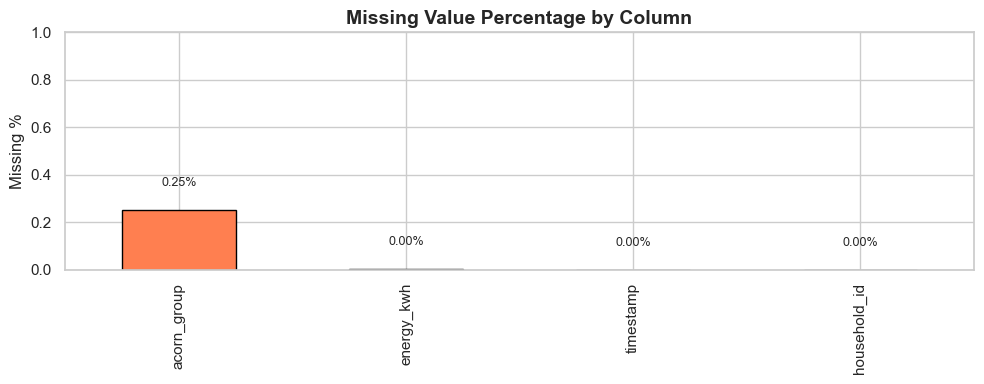

In [25]:
# Missing value heatmap by column
fig, ax = plt.subplots(figsize=(10, 4))
missing_pct = (df_energy.isnull().sum() / len(df_energy) * 100).sort_values(ascending=False)
missing_pct.plot(kind='bar', ax=ax, color='coral', edgecolor='black')
ax.set_title('Missing Value Percentage by Column', fontsize=14, fontweight='bold')
ax.set_ylabel('Missing %')
ax.set_ylim(0, max(missing_pct.max() * 1.2, 1))
for i, v in enumerate(missing_pct):
    ax.text(i, v + 0.1, f'{v:.2f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

<p class="usecase-subsection-header">Aggregate to Neighborhood-Level Hourly Demand</p>

Individual household data is noisy. We aggregate to **ACORN group level** (neighborhood proxy) at **hourly resolution** for more stable forecasting targets.

In [26]:
# Drop rows with missing energy or timestamp
df_energy = df_energy.dropna(subset=['timestamp', 'energy_kwh'])

# Remove negative / extreme outlier readings
q99 = df_energy['energy_kwh'].quantile(0.99)
df_energy = df_energy[(df_energy['energy_kwh'] >= 0) & (df_energy['energy_kwh'] <= q99)]
print(f"Rows after cleaning: {len(df_energy):,}")

# Floor timestamps to hourly for aggregation
df_energy['hour'] = df_energy['timestamp'].dt.floor('h')

# Determine grouping column
if 'acorn_group' in df_energy.columns and df_energy['acorn_group'].notna().sum() > 0:
    group_col = 'acorn_group'
    # Keep only valid ACORN groups
    df_energy = df_energy[df_energy['acorn_group'].notna()]
    print(f"Grouping by ACORN group ({df_energy[group_col].nunique()} groups)")
else:
    # Fallback: create a single "city" group
    df_energy['neighborhood'] = 'London'
    group_col = 'neighborhood'
    print("No ACORN data — aggregating city-wide.")

# Aggregate: sum kWh per neighborhood per hour
df_agg = (
    df_energy
    .groupby([group_col, 'hour'])
    .agg(
        total_kwh=('energy_kwh', 'sum'),
        num_meters=('household_id', 'nunique'),
        mean_kwh=('energy_kwh', 'mean'),
    )
    .reset_index()
    .rename(columns={'hour': 'timestamp', group_col: 'neighborhood'})
)

print(f"\nAggregated dataset: {len(df_agg):,} rows")
print(f"Neighborhoods: {df_agg['neighborhood'].nunique()}")
print(f"Time range: {df_agg['timestamp'].min()} → {df_agg['timestamp'].max()}")
df_agg.head(10)

Rows after cleaning: 14,593,236
Grouping by ACORN group (2 groups)

Aggregated dataset: 39,485 rows
Neighborhoods: 2
Time range: 2011-11-23 12:00:00 → 2014-02-28 00:00:00


,neighborhood,timestamp,total_kwh,num_meters,mean_kwh
0,Adversity,2011-11-23 12:00:00,0.115,1,0.1150
1,Adversity,2011-11-23 13:00:00,0.585,1,0.2925
2,Adversity,2011-11-23 14:00:00,0.306,1,0.1530
3,Adversity,2011-11-23 15:00:00,0.263,1,0.1315
4,Adversity,2011-11-23 16:00:00,0.322,1,0.1610
5,Adversity,2011-11-23 17:00:00,0.397,1,0.1985
6,Adversity,2011-11-23 18:00:00,0.423,1,0.2115
7,Adversity,2011-11-23 19:00:00,1.146,1,0.5730
8,Adversity,2011-11-23 20:00:00,1.095,1,0.5475
9,Adversity,2011-11-23 21:00:00,0.310,1,0.1550


---

<div class="usecase-section-header">1.4 Exploratory Data Analysis (EDA)</div>

<p class="usecase-subsection-header">1.4.1 Overall Demand Distribution</p>

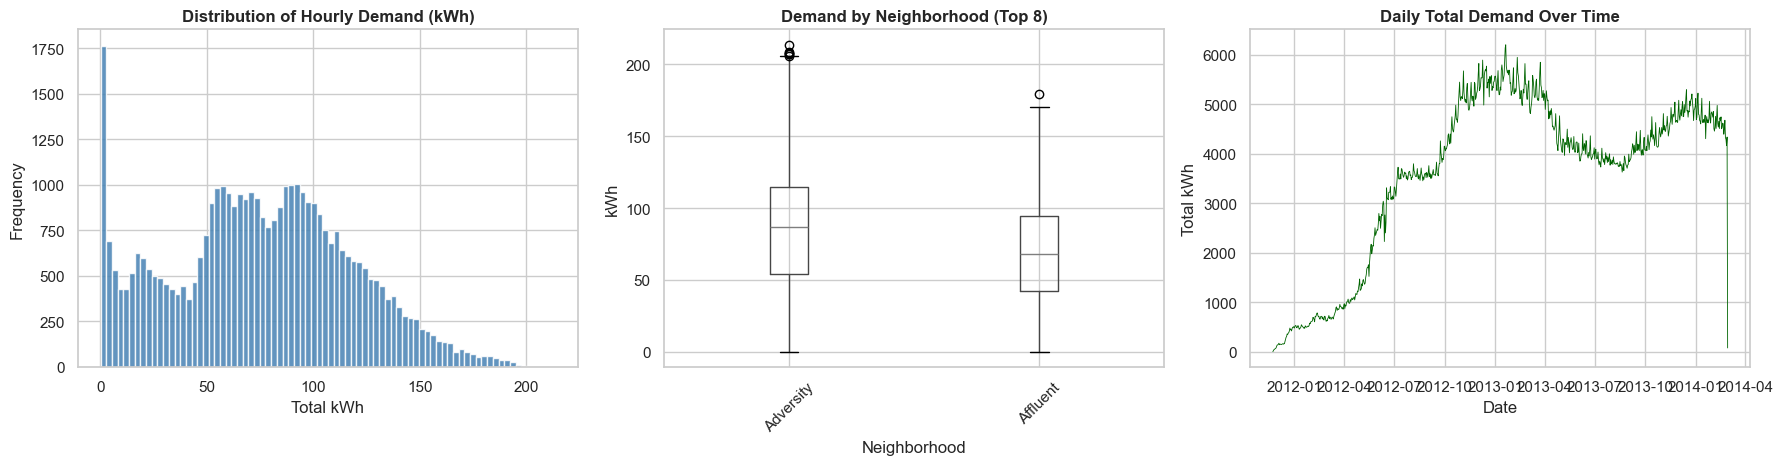

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram of total hourly demand
axes[0].hist(df_agg['total_kwh'], bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Hourly Demand (kWh)', fontweight='bold')
axes[0].set_xlabel('Total kWh')
axes[0].set_ylabel('Frequency')

# Box plot by neighborhood (top 8)
top_neighborhoods = df_agg.groupby('neighborhood')['total_kwh'].median().nlargest(8).index
df_top = df_agg[df_agg['neighborhood'].isin(top_neighborhoods)]
df_top.boxplot(column='total_kwh', by='neighborhood', ax=axes[1], rot=45)
axes[1].set_title('Demand by Neighborhood (Top 8)', fontweight='bold')
axes[1].set_xlabel('Neighborhood')
axes[1].set_ylabel('kWh')
axes[1].get_figure().suptitle('')

# Time series of total demand (all neighborhoods combined)
daily_total = df_agg.groupby('timestamp')['total_kwh'].sum().resample('D').sum()
axes[2].plot(daily_total.index, daily_total.values, linewidth=0.6, color='darkgreen')
axes[2].set_title('Daily Total Demand Over Time', fontweight='bold')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Total kWh')

plt.tight_layout()
plt.show()

<p class="usecase-subsection-header">1.4.2 Temporal Patterns — Hour of Day, Day of Week, Month</p>

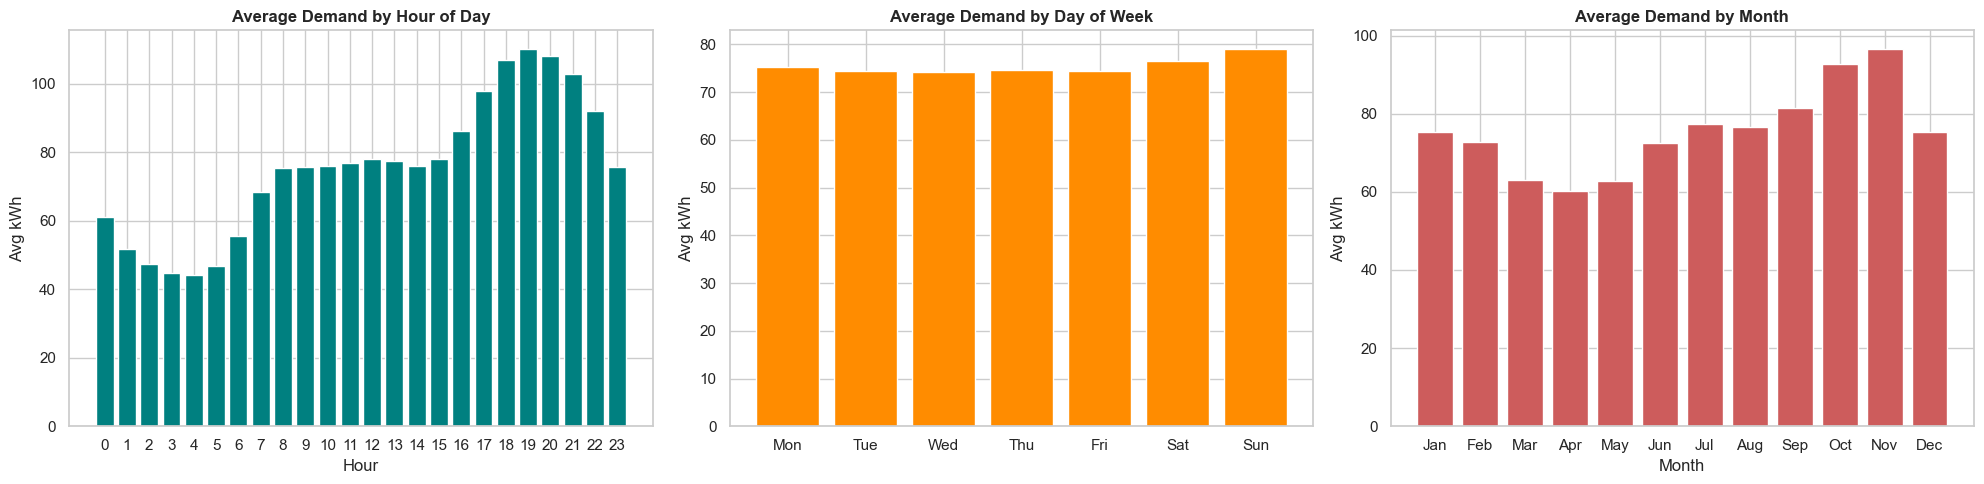

In [28]:
df_agg['hour_of_day'] = df_agg['timestamp'].dt.hour
df_agg['day_of_week'] = df_agg['timestamp'].dt.dayofweek
df_agg['month'] = df_agg['timestamp'].dt.month
df_agg['day_name'] = df_agg['timestamp'].dt.day_name()

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Hourly profile
hourly_avg = df_agg.groupby('hour_of_day')['total_kwh'].mean()
axes[0].bar(hourly_avg.index, hourly_avg.values, color='teal', edgecolor='white')
axes[0].set_title('Average Demand by Hour of Day', fontweight='bold')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Avg kWh')
axes[0].set_xticks(range(0, 24))

# Day of week profile
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_avg = df_agg.groupby('day_name')['total_kwh'].mean().reindex(day_order)
axes[1].bar(range(7), dow_avg.values, color='darkorange', edgecolor='white')
axes[1].set_title('Average Demand by Day of Week', fontweight='bold')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
axes[1].set_ylabel('Avg kWh')

# Monthly profile
monthly_avg = df_agg.groupby('month')['total_kwh'].mean()
axes[2].bar(monthly_avg.index, monthly_avg.values, color='indianred', edgecolor='white')
axes[2].set_title('Average Demand by Month', fontweight='bold')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Avg kWh')
axes[2].set_xticks(range(1, 13))
axes[2].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

plt.tight_layout()
plt.show()

<p class="usecase-subsection-header">1.4.3 Seasonal Demand Heatmap (Hour × Month)</p>

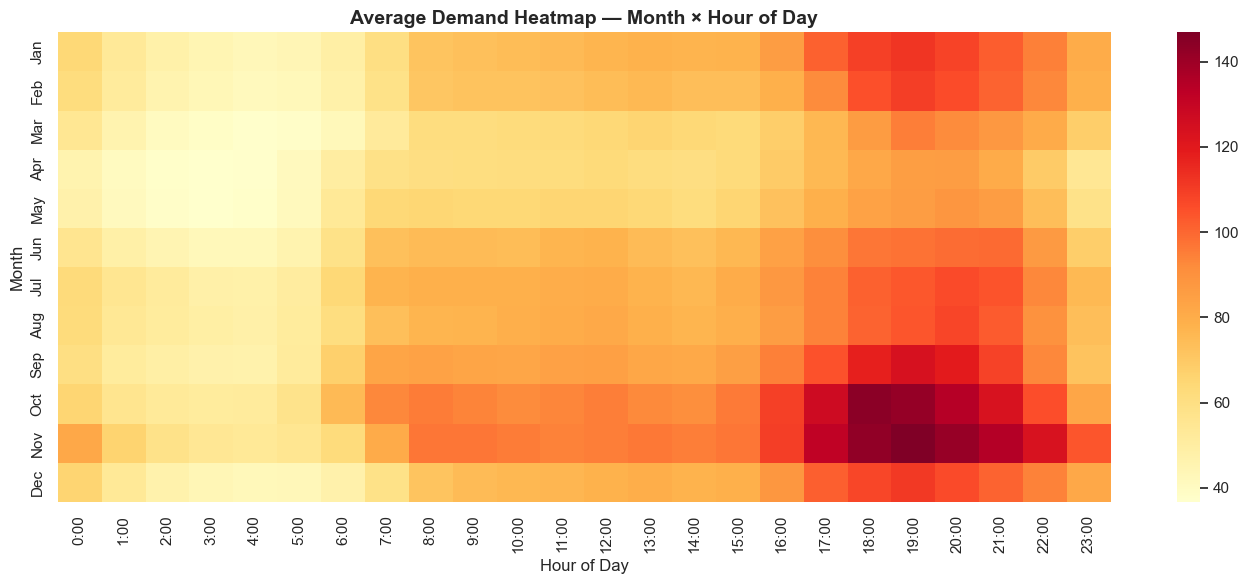

In [29]:
pivot = df_agg.groupby(['month', 'hour_of_day'])['total_kwh'].mean().unstack()

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    pivot, cmap='YlOrRd', annot=False, fmt='.0f',
    xticklabels=[f'{h}:00' for h in range(24)],
    yticklabels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    ax=ax
)
ax.set_title('Average Demand Heatmap — Month × Hour of Day', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Month')
plt.tight_layout()
plt.show()

<p class="usecase-subsection-header">1.4.4 Neighborhood Comparison (Interactive)</p>

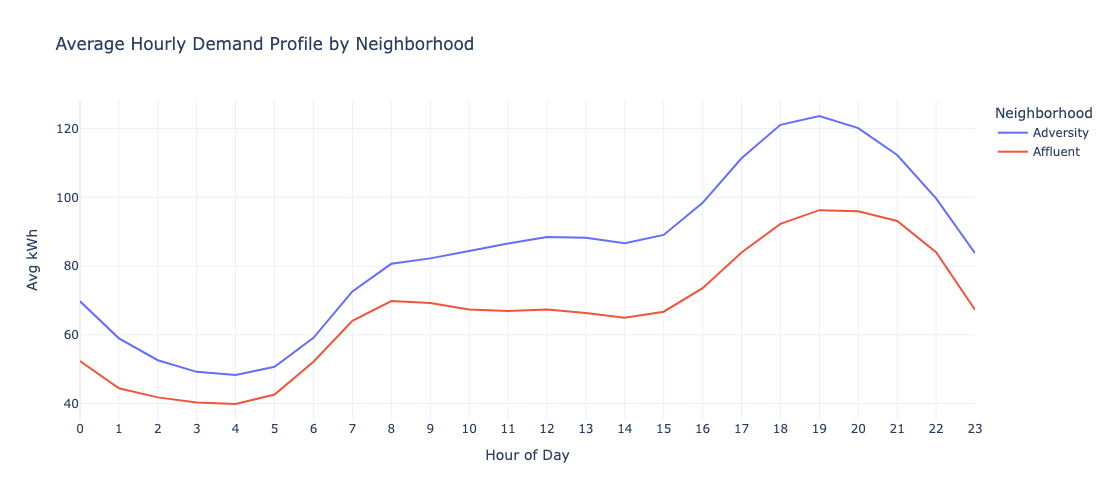

In [30]:
# Interactive hourly profile by neighborhood
hourly_neigh = df_agg.groupby(['neighborhood', 'hour_of_day'])['total_kwh'].mean().reset_index()

fig = px.line(
    hourly_neigh, x='hour_of_day', y='total_kwh', color='neighborhood',
    title='Average Hourly Demand Profile by Neighborhood',
    labels={'hour_of_day': 'Hour of Day', 'total_kwh': 'Avg kWh', 'neighborhood': 'Neighborhood'},
)
fig.update_layout(xaxis=dict(dtick=1), template='plotly_white', height=500)
fig.show()

<p class="usecase-subsection-header">1.4.5 Outlier Detection</p>

IQR bounds: [-41.79, 193.19]
Outlier rows: 51 (0.13%)


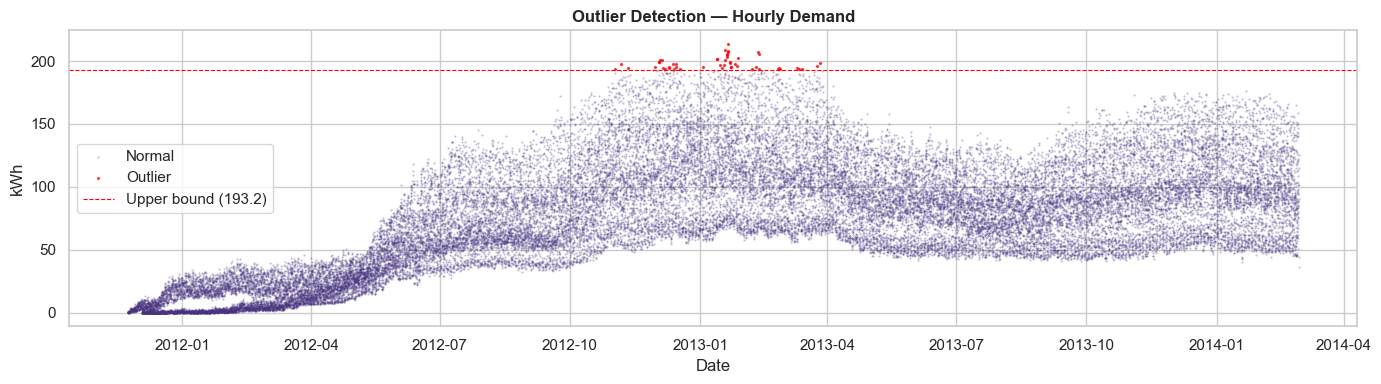

In [31]:
# IQR-based outlier detection on aggregated demand
Q1 = df_agg['total_kwh'].quantile(0.25)
Q3 = df_agg['total_kwh'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_agg[(df_agg['total_kwh'] < lower_bound) | (df_agg['total_kwh'] > upper_bound)]
print(f"IQR bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Outlier rows: {len(outliers):,} ({len(outliers)/len(df_agg)*100:.2f}%)")

fig, ax = plt.subplots(figsize=(14, 4))
ax.scatter(df_agg['timestamp'], df_agg['total_kwh'], s=0.3, alpha=0.3, label='Normal')
ax.scatter(outliers['timestamp'], outliers['total_kwh'], s=2, color='red', alpha=0.6, label='Outlier')
ax.axhline(upper_bound, color='red', linestyle='--', linewidth=0.8, label=f'Upper bound ({upper_bound:.1f})')
ax.set_title('Outlier Detection — Hourly Demand', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('kWh')
ax.legend()
plt.tight_layout()
plt.show()

---

<div class="usecase-section-header">1.5 Weather Data Integration</div>

Merge weather features into the aggregated demand data, aligned by hourly timestamp.

In [32]:
if df_weather is not None:
    print(f"Weather data shape: {df_weather.shape}")
    print(f"Weather columns: {list(df_weather.columns)}")
    print(f"\nSample:")
    display(df_weather.head())
    print(f"\nMissing values:")
    print(df_weather.isnull().sum())
else:
    print("No weather data available.")

Weather data shape: (21165, 12)
Weather columns: ['visibility', 'windbearing', 'temperature', 'time', 'dewpoint', 'pressure', 'apparenttemperature', 'windspeed', 'preciptype', 'icon', 'humidity', 'summary']

Sample:


,visibility,windbearing,temperature,time,dewpoint,pressure,apparenttemperature,windspeed,preciptype,icon,humidity,summary
0,5.97,104,10.24,2011-11-11 00:00:00,8.86,1016.76,10.24,2.77,rain,partly-cloudy-night,0.91,Partly Cloudy
1,4.88,99,9.76,2011-11-11 01:00:00,8.83,1016.63,8.24,2.95,rain,partly-cloudy-night,0.94,Partly Cloudy
2,3.70,98,9.46,2011-11-11 02:00:00,8.79,1016.36,7.76,3.17,rain,partly-cloudy-night,0.96,Partly Cloudy
3,3.12,99,9.23,2011-11-11 03:00:00,8.63,1016.28,7.44,3.25,rain,fog,0.96,Foggy
4,1.85,111,9.26,2011-11-11 04:00:00,9.21,1015.98,7.24,3.70,rain,fog,1.00,Foggy



Missing values:
visibility              0
windbearing             0
temperature             0
time                    0
dewpoint                0
pressure               13
apparenttemperature     0
windspeed               0
preciptype              0
icon                    0
humidity                0
summary                 0
dtype: int64


In [33]:
if df_weather is not None:
    # Identify and parse the timestamp column in weather data
    time_col = [c for c in df_weather.columns if 'time' in c or 'date' in c or 'tstp' in c]
    if time_col:
        time_col = time_col[0]
        df_weather['timestamp'] = pd.to_datetime(df_weather[time_col], errors='coerce')
        df_weather['timestamp'] = df_weather['timestamp'].dt.floor('h')
        df_weather = df_weather.drop_duplicates(subset='timestamp')

        # Select key weather features (adapt column names to dataset)
        weather_feature_candidates = [
            'temperature', 'temperaturemax', 'temperaturemin', 'temperaturehigh', 'temperaturelow',
            'apparenttemperature', 'humidity', 'windspeed', 'windbearing',
            'visibility', 'dewpoint', 'pressure', 'cloudcover',
            'precipintensity', 'precipprobability', 'preciptype',
            'icon', 'summary'
        ]
        available_weather_cols = ['timestamp'] + [
            c for c in df_weather.columns if c in weather_feature_candidates
        ]
        df_weather_clean = df_weather[available_weather_cols].copy()

        # Convert numeric columns
        for col in df_weather_clean.columns:
            if col not in ['timestamp', 'icon', 'summary', 'preciptype']:
                df_weather_clean[col] = pd.to_numeric(df_weather_clean[col], errors='coerce')

        # Fill small weather gaps with interpolation
        numeric_cols = df_weather_clean.select_dtypes(include=[np.number]).columns
        df_weather_clean[numeric_cols] = df_weather_clean[numeric_cols].interpolate(method='linear', limit=6)

        print(f"Weather features prepared: {list(df_weather_clean.columns)}")
        print(f"Weather date range: {df_weather_clean['timestamp'].min()} → {df_weather_clean['timestamp'].max()}")

        # Merge into aggregated demand data
        df_merged = df_agg.merge(df_weather_clean, on='timestamp', how='left')
        weather_missing = df_merged[numeric_cols[0]].isnull().sum() if len(numeric_cols) > 0 else 0
        print(f"\nMerged dataset: {len(df_merged):,} rows")
        print(f"Weather match rate: {(1 - weather_missing / len(df_merged)) * 100:.1f}%")
    else:
        print("Could not identify timestamp column in weather data.")
        df_merged = df_agg.copy()
else:
    print("No weather data — proceeding without weather features.")
    df_merged = df_agg.copy()

Weather features prepared: ['timestamp', 'visibility', 'windbearing', 'temperature', 'dewpoint', 'pressure', 'apparenttemperature', 'windspeed', 'preciptype', 'icon', 'humidity', 'summary']
Weather date range: 2011-11-01 00:00:00 → 2014-03-31 22:00:00

Merged dataset: 39,485 rows
Weather match rate: 100.0%


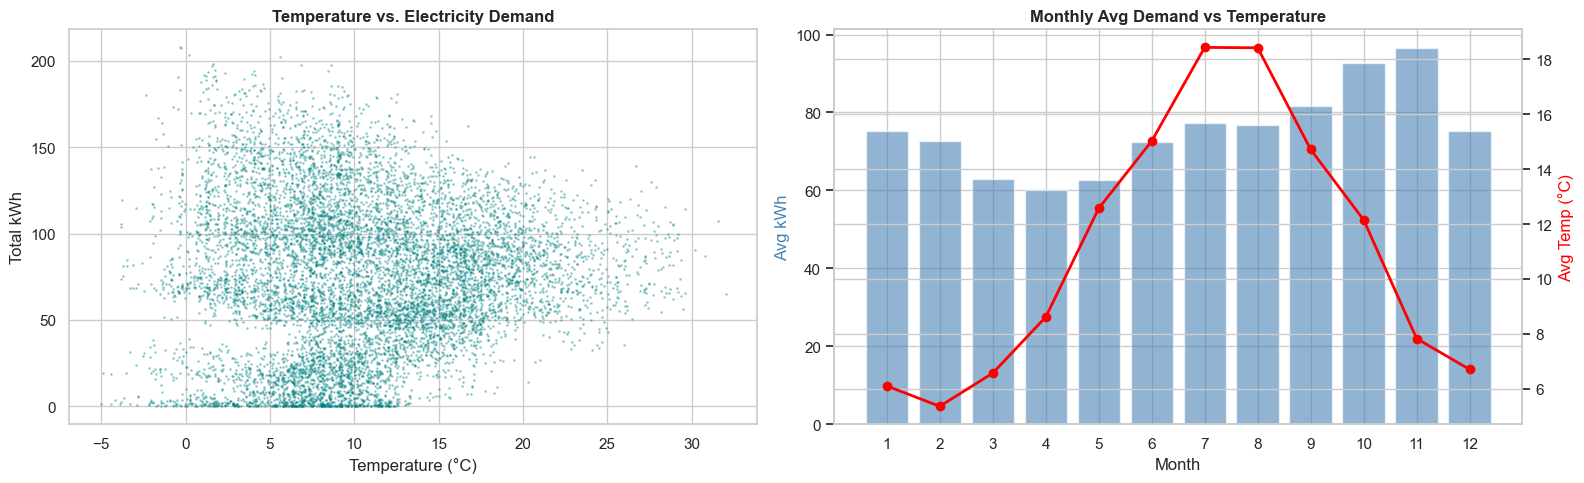

In [34]:
# Visualize temperature vs. demand relationship
if 'temperature' in df_merged.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Scatter
    sample = df_merged.dropna(subset=['temperature']).sample(min(10000, len(df_merged)), random_state=42)
    axes[0].scatter(sample['temperature'], sample['total_kwh'], s=1, alpha=0.3, color='teal')
    axes[0].set_title('Temperature vs. Electricity Demand', fontweight='bold')
    axes[0].set_xlabel('Temperature (°C)')
    axes[0].set_ylabel('Total kWh')

    # Monthly avg temperature and demand dual-axis
    monthly_temp = df_merged.groupby('month')['temperature'].mean()
    monthly_demand = df_merged.groupby('month')['total_kwh'].mean()
    ax2 = axes[1].twinx()
    axes[1].bar(monthly_demand.index, monthly_demand.values, alpha=0.6, color='steelblue', label='Demand')
    ax2.plot(monthly_temp.index, monthly_temp.values, 'o-', color='red', linewidth=2, label='Temperature')
    axes[1].set_title('Monthly Avg Demand vs Temperature', fontweight='bold')
    axes[1].set_xlabel('Month')
    axes[1].set_ylabel('Avg kWh', color='steelblue')
    ax2.set_ylabel('Avg Temp (°C)', color='red')
    axes[1].set_xticks(range(1, 13))

    plt.tight_layout()
    plt.show()
else:
    print("Temperature column not available for visualization.")

---

<div class="usecase-section-header">1.6 Feature Engineering</div>

We create five categories of features:

| Category | Features |
|----------|----------|
| **Temporal** | hour, day_of_week, month, quarter, is_weekend, is_holiday |
| **Lag** | demand at t−1, t−24, t−48, t−168 |
| **Rolling** | 24h mean, 24h std, 7d mean |
| **Weather** | temperature, humidity, wind, heating/cooling degree days |
| **Derived** | peak_hour flag, temp×demand interaction |

In [35]:
# Work on a per-neighborhood basis to avoid cross-contamination of lag/rolling features
def engineer_features(df):
    """Apply feature engineering to a single neighborhood's time-series."""
    df = df.sort_values('timestamp').copy()

    # --- Temporal features ---
    df['hour'] = df['timestamp'].dt.hour
    df['day_of_week'] = df['timestamp'].dt.dayofweek
    df['month'] = df['timestamp'].dt.month
    df['quarter'] = df['timestamp'].dt.quarter
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    df['day_of_year'] = df['timestamp'].dt.dayofyear

    # Cyclical encoding for hour and month
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

    # --- Lag features ---
    for lag in [1, 2, 3, 6, 12, 24, 48, 168]:
        df[f'lag_{lag}h'] = df['total_kwh'].shift(lag)

    # --- Rolling statistics ---
    df['rolling_24h_mean'] = df['total_kwh'].rolling(window=24, min_periods=12).mean()
    df['rolling_24h_std'] = df['total_kwh'].rolling(window=24, min_periods=12).std()
    df['rolling_7d_mean'] = df['total_kwh'].rolling(window=168, min_periods=84).mean()
    df['rolling_7d_std'] = df['total_kwh'].rolling(window=168, min_periods=84).std()

    # Ratio of current demand to rolling mean
    df['demand_ratio_24h'] = df['total_kwh'] / df['rolling_24h_mean'].replace(0, np.nan)

    # --- Weather-derived features ---
    if 'temperature' in df.columns:
        base_temp = 18.0  # base temperature for degree-day calculation
        df['heating_degree'] = np.maximum(base_temp - df['temperature'], 0)
        df['cooling_degree'] = np.maximum(df['temperature'] - base_temp, 0)
        df['temp_squared'] = df['temperature'] ** 2  # captures nonlinear temp-demand relationship

    # --- Derived features ---
    df['is_peak_hour'] = df['hour'].isin([7, 8, 9, 17, 18, 19, 20]).astype(int)

    return df

# Apply per neighborhood
neighborhoods = df_merged['neighborhood'].unique()
featured_parts = []
for neigh in neighborhoods:
    df_neigh = df_merged[df_merged['neighborhood'] == neigh].copy()
    df_neigh = engineer_features(df_neigh)
    featured_parts.append(df_neigh)

df_featured = pd.concat(featured_parts, ignore_index=True)

print(f"Feature-engineered dataset: {len(df_featured):,} rows × {len(df_featured.columns)} columns")
print(f"\nNew columns:")
print([c for c in df_featured.columns if c not in df_merged.columns])

Feature-engineered dataset: 39,485 rows × 47 columns

New columns:
['hour', 'quarter', 'is_weekend', 'day_of_year', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'lag_1h', 'lag_2h', 'lag_3h', 'lag_6h', 'lag_12h', 'lag_24h', 'lag_48h', 'lag_168h', 'rolling_24h_mean', 'rolling_24h_std', 'rolling_7d_mean', 'rolling_7d_std', 'demand_ratio_24h', 'heating_degree', 'cooling_degree', 'temp_squared', 'is_peak_hour']


In [36]:
# Drop rows where lag/rolling features are NaN (initial window period)
rows_before = len(df_featured)
df_featured = df_featured.dropna(subset=['lag_168h', 'rolling_7d_mean'])
rows_after = len(df_featured)
print(f"Dropped {rows_before - rows_after:,} rows from warm-up period.")
print(f"Final featured dataset: {rows_after:,} rows")

df_featured.head()

Dropped 336 rows from warm-up period.
Final featured dataset: 39,149 rows


,neighborhood,timestamp,total_kwh,num_meters,mean_kwh,hour_of_day,day_of_week,month,day_name,visibility,...,lag_168h,rolling_24h_mean,rolling_24h_std,rolling_7d_mean,rolling_7d_std,demand_ratio_24h,heating_degree,cooling_degree,temp_squared,is_peak_hour
168,Adversity,2011-11-30 12:00:00,6.737,11,0.306227,12,2,11,Wednesday,13.02,...,0.115,4.193875,1.508277,2.322375,1.523152,1.606390,6.13,0.0,140.8969,0
169,Adversity,2011-11-30 13:00:00,7.473,11,0.339682,13,2,11,Wednesday,13.07,...,0.585,4.294583,1.643018,2.363375,1.568146,1.740099,6.33,0.0,136.1889,0
170,Adversity,2011-11-30 14:00:00,5.823,11,0.264682,14,2,11,Wednesday,13.52,...,0.306,4.339958,1.670488,2.396214,1.582505,1.341718,6.19,0.0,139.4761,0
171,Adversity,2011-11-30 15:00:00,5.498,11,0.249909,15,2,11,Wednesday,13.07,...,0.263,4.390833,1.686999,2.427375,1.591763,1.252154,6.67,0.0,128.3689,0
172,Adversity,2011-11-30 16:00:00,7.759,11,0.352682,16,2,11,Wednesday,13.52,...,0.322,4.458750,1.789703,2.471643,1.635668,1.740174,7.53,0.0,109.6209,0


<p class="usecase-subsection-header">Feature Correlation with Target</p>

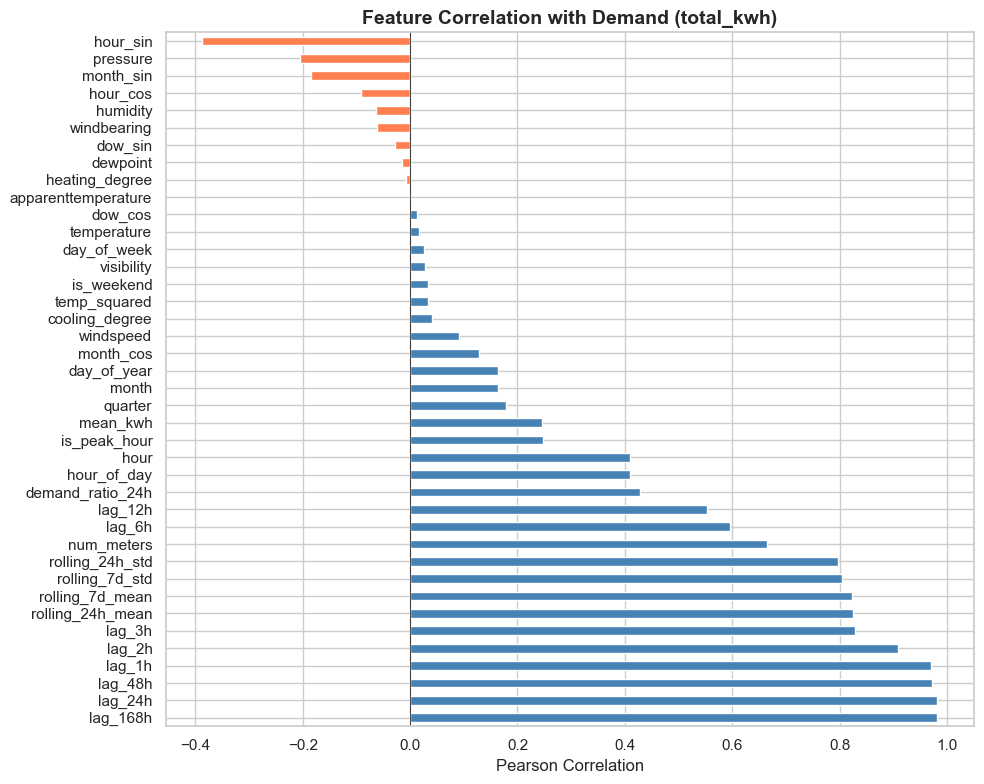

In [37]:
# Correlation of numeric features with total_kwh
numeric_feats = df_featured.select_dtypes(include=[np.number]).columns.tolist()
corr_with_target = df_featured[numeric_feats].corr()['total_kwh'].drop('total_kwh').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
corr_with_target.plot(kind='barh', ax=ax, color=corr_with_target.apply(
    lambda x: 'steelblue' if x >= 0 else 'coral'
))
ax.set_title('Feature Correlation with Demand (total_kwh)', fontsize=14, fontweight='bold')
ax.set_xlabel('Pearson Correlation')
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

---

<div class="usecase-section-header">1.7 Preprocessing Pipeline</div>

Steps:
1. Select feature columns and target
2. Scale features with MinMaxScaler
3. Chronological train / validation / test split (70 / 15 / 15)
4. Create sliding window sequences for model input
5. Export everything to `data/processed/`

In [38]:
# Define feature columns and target
TARGET = 'total_kwh'

EXCLUDE_COLS = ['timestamp', 'neighborhood', 'household_id', 'day_name',
                'icon', 'summary', 'preciptype', 'num_meters']

FEATURE_COLS = [
    c for c in df_featured.columns
    if c not in EXCLUDE_COLS and c != TARGET
    and df_featured[c].dtype in ['float64', 'float32', 'int64', 'int32']
]

print(f"Target: {TARGET}")
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")

Target: total_kwh
Features (39): ['mean_kwh', 'hour_of_day', 'day_of_week', 'month', 'visibility', 'windbearing', 'temperature', 'dewpoint', 'pressure', 'apparenttemperature', 'windspeed', 'humidity', 'hour', 'quarter', 'is_weekend', 'day_of_year', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'lag_1h', 'lag_2h', 'lag_3h', 'lag_6h', 'lag_12h', 'lag_24h', 'lag_48h', 'lag_168h', 'rolling_24h_mean', 'rolling_24h_std', 'rolling_7d_mean', 'rolling_7d_std', 'demand_ratio_24h', 'heating_degree', 'cooling_degree', 'temp_squared', 'is_peak_hour']


In [39]:
# Process each neighborhood independently
neighborhoods = df_featured['neighborhood'].unique()
print(f"Processing {len(neighborhoods)} neighborhood(s)...")

# We'll demonstrate with a single neighborhood for the sequence model.
# For multi-neighborhood, repeat or concatenate.
# Pick the neighborhood with the most data points.
neighborhood_counts = df_featured.groupby('neighborhood').size()
primary_neighborhood = neighborhood_counts.idxmax()
print(f"Primary neighborhood: '{primary_neighborhood}' ({neighborhood_counts[primary_neighborhood]:,} rows)")

df_primary = (
    df_featured[df_featured['neighborhood'] == primary_neighborhood]
    .sort_values('timestamp')
    .reset_index(drop=True)
)

# Fill any remaining NaN in features
df_primary[FEATURE_COLS] = df_primary[FEATURE_COLS].ffill().bfill()
df_primary[TARGET] = df_primary[TARGET].ffill()

print(f"Primary neighborhood data: {len(df_primary):,} rows")
print(f"Remaining NaNs: {df_primary[FEATURE_COLS + [TARGET]].isnull().sum().sum()}")

Processing 2 neighborhood(s)...
Primary neighborhood: 'Adversity' (19,693 rows)
Primary neighborhood data: 19,693 rows
Remaining NaNs: 0


In [40]:
# Chronological split — 70% train, 15% val, 15% test
n = len(df_primary)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

df_train = df_primary.iloc[:train_end]
df_val = df_primary.iloc[train_end:val_end]
df_test = df_primary.iloc[val_end:]

print(f"Train: {len(df_train):,} rows  ({df_train['timestamp'].min().date()} → {df_train['timestamp'].max().date()})")
print(f"Val:   {len(df_val):,} rows  ({df_val['timestamp'].min().date()} → {df_val['timestamp'].max().date()})")
print(f"Test:  {len(df_test):,} rows  ({df_test['timestamp'].min().date()} → {df_test['timestamp'].max().date()})")

Train: 13,785 rows  (2011-11-30 → 2013-06-26)
Val:   2,954 rows  (2013-06-26 → 2013-10-27)
Test:  2,954 rows  (2013-10-27 → 2014-02-28)


In [41]:
# Fit scaler on training data only (no data leakage)
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

train_features = feature_scaler.fit_transform(df_train[FEATURE_COLS])
val_features = feature_scaler.transform(df_val[FEATURE_COLS])
test_features = feature_scaler.transform(df_test[FEATURE_COLS])

train_target = target_scaler.fit_transform(df_train[[TARGET]])
val_target = target_scaler.transform(df_val[[TARGET]])
test_target = target_scaler.transform(df_test[[TARGET]])

print(f"Feature matrix shapes: Train {train_features.shape}, Val {val_features.shape}, Test {test_features.shape}")
print(f"Target shapes:         Train {train_target.shape}, Val {val_target.shape}, Test {test_target.shape}")

Feature matrix shapes: Train (13785, 39), Val (2954, 39), Test (2954, 39)
Target shapes:         Train (13785, 1), Val (2954, 1), Test (2954, 1)


In [42]:
# Create sliding window sequences
WINDOW_SIZE = 168     # 1 week of hourly data as input
FORECAST_HORIZON = 24 # predict next 24 hours

def create_sequences(features, target, window_size, horizon):
    """Create input/output sequences for time-series forecasting."""
    X, y = [], []
    for i in range(len(features) - window_size - horizon + 1):
        X.append(features[i : i + window_size])
        y.append(target[i + window_size : i + window_size + horizon].flatten())
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_features, train_target, WINDOW_SIZE, FORECAST_HORIZON)
X_val, y_val = create_sequences(val_features, val_target, WINDOW_SIZE, FORECAST_HORIZON)
X_test, y_test = create_sequences(test_features, test_target, WINDOW_SIZE, FORECAST_HORIZON)

print(f"Sliding window sequences created (window={WINDOW_SIZE}h, horizon={FORECAST_HORIZON}h):")
print(f"  X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape}  y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape}  y_test:  {y_test.shape}")

Sliding window sequences created (window=168h, horizon=24h):
  X_train: (13594, 168, 39)  y_train: (13594, 24)
  X_val:   (2763, 168, 39)  y_val:   (2763, 24)
  X_test:  (2763, 168, 39)  y_test:  (2763, 24)


<p class="usecase-subsection-header">Visualize a Sample Sequence</p>

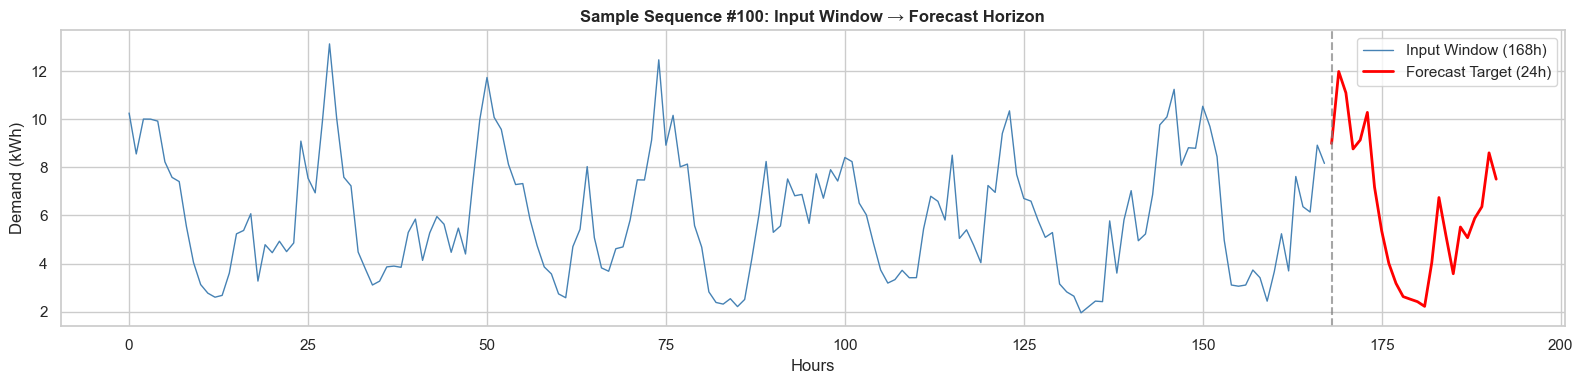

In [43]:
# Visualize one training sample: input window and forecast target
sample_idx = 100

fig, ax = plt.subplots(figsize=(16, 4))

# Find the column index for total_kwh in features (if it's a lag or the target itself)
# We'll use the scaled target for visualization
input_window = target_scaler.inverse_transform(
    train_target[sample_idx : sample_idx + WINDOW_SIZE]
).flatten()
forecast_actual = target_scaler.inverse_transform(
    y_train[sample_idx].reshape(-1, 1)
).flatten()

t_input = range(WINDOW_SIZE)
t_forecast = range(WINDOW_SIZE, WINDOW_SIZE + FORECAST_HORIZON)

ax.plot(t_input, input_window, color='steelblue', linewidth=1, label='Input Window (168h)')
ax.plot(t_forecast, forecast_actual, color='red', linewidth=2, label=f'Forecast Target ({FORECAST_HORIZON}h)')
ax.axvline(WINDOW_SIZE, color='gray', linestyle='--', alpha=0.7)
ax.set_title(f'Sample Sequence #{sample_idx}: Input Window → Forecast Horizon', fontweight='bold')
ax.set_xlabel('Hours')
ax.set_ylabel('Demand (kWh)')
ax.legend()
plt.tight_layout()
plt.show()

---

<div class="usecase-section-header">1.8 Export Processed Data</div>

Save all processed artifacts to `data/processed/` for use in Step 2.

In [44]:
PROCESSED_DIR = 'data/processed'
os.makedirs(PROCESSED_DIR, exist_ok=True)

# Save numpy arrays
np.save(os.path.join(PROCESSED_DIR, 'X_train.npy'), X_train)
np.save(os.path.join(PROCESSED_DIR, 'y_train.npy'), y_train)
np.save(os.path.join(PROCESSED_DIR, 'X_val.npy'), X_val)
np.save(os.path.join(PROCESSED_DIR, 'y_val.npy'), y_val)
np.save(os.path.join(PROCESSED_DIR, 'X_test.npy'), X_test)
np.save(os.path.join(PROCESSED_DIR, 'y_test.npy'), y_test)

# Save scalers for inverse-transforming predictions later
with open(os.path.join(PROCESSED_DIR, 'feature_scaler.pkl'), 'wb') as f:
    pickle.dump(feature_scaler, f)
with open(os.path.join(PROCESSED_DIR, 'target_scaler.pkl'), 'wb') as f:
    pickle.dump(target_scaler, f)

# Save feature column names and config
config = {
    'feature_columns': FEATURE_COLS,
    'target_column': TARGET,
    'window_size': WINDOW_SIZE,
    'forecast_horizon': FORECAST_HORIZON,
    'primary_neighborhood': primary_neighborhood,
    'num_features': len(FEATURE_COLS),
    'train_samples': len(X_train),
    'val_samples': len(X_val),
    'test_samples': len(X_test),
}
with open(os.path.join(PROCESSED_DIR, 'config.pkl'), 'wb') as f:
    pickle.dump(config, f)

# Save the full featured DataFrame (useful for further analysis)
df_featured.to_csv(os.path.join(PROCESSED_DIR, 'df_featured.csv'), index=False)

print("Saved to data/processed/:")
for fname in sorted(os.listdir(PROCESSED_DIR)):
    fsize = os.path.getsize(os.path.join(PROCESSED_DIR, fname)) / (1024 * 1024)
    print(f"  {fname:30s} {fsize:8.2f} MB")

Saved to data/processed/:
  X_test.npy                       138.12 MB
  X_train.npy                      679.53 MB
  X_val.npy                        138.12 MB
  config.pkl                         0.00 MB
  df_featured.csv                   17.48 MB
  feature_scaler.pkl                 0.00 MB
  step2_results.pkl                  1.27 MB
  target_scaler.pkl                  0.00 MB
  y_test.npy                         0.51 MB
  y_train.npy                        2.49 MB
  y_val.npy                          0.51 MB


---

<div class="usecase-section-header">Summary</div>

| Item | Value |
|------|-------|
| **Dataset** | UK Smart Meter (London) |
| **Aggregation** | Neighborhood-level (ACORN group), hourly |
| **Features** | Temporal, lag, rolling, weather, derived |
| **Scaling** | MinMaxScaler (fit on train only) |
| **Input window** | 168 hours (1 week) |
| **Forecast horizon** | 24 hours |
| **Split** | 70% train / 15% val / 15% test (chronological) |

The processed data is saved in `data/processed/` and ready for model development.